# Training a REINFORCE racing agent

This notebook develops the project-owned REINFORCE agent from its policy-gradient motivation through a complete racing run. It uses the readable loop in `training/engines/reinforce.py`, making every collection and update boundary visible.

The exact bounded-policy, return, and loss conventions come from [`docs/LEARNING.md`](../docs/LEARNING.md). The racing MDP and procedural circuit model are specified in [`docs/MDP.md`](../docs/MDP.md) and [`docs/TRACK.md`](../docs/TRACK.md).

## Why start with REINFORCE?

The car has two continuous controls, throttle/brake and steering. A value-based method would need to maximize an action-value approximation over this continuous two-dimensional action space at every decision. Policy-gradient methods avoid that inner optimization by representing the policy directly and changing its parameters in the direction of higher expected return.

The actor maps the normalized Frenet observation \(O_t\) to the mean of a diagonal Gaussian over an unbounded action \(U_t\). Sampling and squashing give

$$
U_t = \mu_\theta(O_t) + \sigma \odot \varepsilon_t,\qquad
A_t = \tanh(U_t),\qquad \varepsilon_t\sim\mathcal N(0,I).
$$

The \(\tanh\) transform keeps both controls in \([-1,1]\). The actor evaluates the corrected density of the bounded action, including the change-of-variables term. The two learned state-independent values $(\sigma_{\mathrm{throttle}})$ and $(\sigma_{\mathrm{steering}})$ are the policy's exploration scales; this project does not impose a separate epsilon or forced exploration-decay schedule.

## The complete REINFORCE update

REINFORCE is an actor-only Monte Carlo algorithm. It must wait for an episode to end because it has no critic from which to bootstrap. For every complete trajectory \(i\), it computes discounted return-to-go backwards:

$$
G_t^i =
\begin{cases}
R_{t+1}^i, & \text{at termination or truncation},\\
R_{t+1}^i + \gamma G_{t+1}^i, & \text{otherwise}.
\end{cases}
$$

Returns are standardized once across every transition in the trajectory batch, giving \(\widetilde G_t^i\). For \(n\) complete episodes, the actor minimizes

$$
\mathcal L_{\mathrm{REINFORCE}}(\theta)
= -\frac{1}{n}\sum_{i=1}^{n}\sum_t
\log\pi_\theta(A_t^i\mid O_t^i)\,
\operatorname{detach}(\widetilde G_t^i).
$$

The score-function estimator is simple and does not introduce value-function bias, which makes REINFORCE the clean baseline for the project. Its weakness is high variance and delayed updates: one poor action can affect every earlier return, and no learning occurs until complete trajectories are available. A2C addresses those limitations by adding a learned state-value baseline and bootstrapped advantages.

## Configuration

The primary stopping rule is `TRAINING_INTERACTION_BUDGET`, not an episode count. Giving the same value to all three notebooks makes their data budgets directly comparable. The default below matches the frozen Experiment 1 planning budget.

Set `TRAIN_ON_RANDOM_CIRCUITS = True` to generate a fresh deterministic procedural circuit for every logical training episode. Episode (e) maps to the same seed for a fixed root in every algorithm; policy sampling and environment reset randomness do not affect that schedule. Greedy evaluation and before/after rendering remain on the fixed reference circuit.

The initial viewer deliberately shows only 20 actions. The final viewer accepts the environment limit of 1,000 actions so a learned lap can unfold completely.

In [1]:
import sys
import warnings
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module="pygame.pkgdata",
)

from agents import ReinforceAgent
from configs import (
    MEDIUM_ACTOR_CONFIG,
    EnvironmentConfig,
    ExecutionConfig,
    LoggingConfig,
    ObservationNormalizationConfig,
    RenderStyle,
    physical_cpu_count,
    StartStateConfig,
    ReinforceConfig,
)
from envs.racing import RacingEnv
from envs.tracks import TrackWithGeometry
from recording import RunCategory
from training.educational_visualization import (
    plot_driving_behavior,
    plot_optimization_and_exploration,
    plot_outcomes_and_lap_time,
    plot_progress_and_efficiency,
    plot_task_performance,
    watch_deterministic_rollout,
)
from training import ReinforceTrainingEngine, TrainingCircuitSchedule
from training.normalization import RunningObservationNormalizer
from utils.random import (
    RunSeedStreams,
    SeedNamespace,
    SeedStream,
    configure_torch_determinism,
)

# Reproducibility and execution
ROOT_SEED = 0
TRAINING_INTERACTION_BUDGET = 2_000_000

# Circuit schedule
TRAIN_ON_RANDOM_CIRCUITS = False
SINGLE_CIRCUIT_SEED = 0

# Actor and REINFORCE
# Rates selected by the pre-experiment calibration in docs/EXPERIMENT.md.
ACTOR_CONFIG = replace(MEDIUM_ACTOR_CONFIG, learning_rate=1e-3)
REINFORCE_CONFIG = ReinforceConfig(
    discount=0.9995,
    completed_episodes_per_update=8,
)
NUM_ENVS = physical_cpu_count()
ENVIRONMENT_CONFIG = EnvironmentConfig()
# Training samples a start pose all around the circuit for state coverage, but
# every greedy evaluation launches from the canonical start line so that the
# reported number always answers the same question and is exactly reproducible.
EVALUATION_CONFIG = replace(
    ENVIRONMENT_CONFIG, start=StartStateConfig(randomized=False)
)
NORMALIZATION_CONFIG = ObservationNormalizationConfig()

# Greedy evaluation and plots
EVALUATION_INTERVAL_INTERACTIONS = 50_000
EVALUATION_EPISODES = 1
MOVING_AVERAGE_WINDOW = 20

# Live rollout dashboard
RENDER_RESET_SEED = 123
VIEWER_MODE = "inline"  # "inline" or "window"
# The broadcast style draws the circuit from the driver's seat with a
# telemetry overlay; the minimal style draws the lap as a diagram.
RENDER_STYLE = RenderStyle.BROADCAST
INITIAL_RENDER_STEPS = 20
FINAL_RENDER_STEPS = ENVIRONMENT_CONFIG.simulation.max_episode_steps
LIVE_FRAME_DELAY = 0.01


## Build the reference circuit, random streams, actor, and engine

A single root identity derives independent actor-initialization, policy-sampling, environment-reset, evaluation, and circuit-generation streams. In random-circuit mode the function below derives a circuit seed from the logical episode index, rather than choosing from a small stored tuple.

In [2]:
execution_config = ExecutionConfig(environment_workers=NUM_ENVS)
configure_torch_determinism(execution_config)
streams = RunSeedStreams(SeedNamespace.MULTI_CIRCUIT_DEVELOPMENT, ROOT_SEED)
track_streams = RunSeedStreams(
    SeedNamespace.EXPERIMENT_2_TRAINING_TRACK,
    ROOT_SEED,
)

reference_track = TrackWithGeometry.generate(
    SINGLE_CIRCUIT_SEED,
    track_config=ENVIRONMENT_CONFIG.track,
    vehicle_config=ENVIRONMENT_CONFIG.vehicle,
)
tracks = (reference_track,)


def training_track_seed(episode_index):
    generator = track_streams.get_numpy_generator(
        SeedStream.TRACK_GENERATION,
        substream_identity=episode_index,
    )
    return int(generator.integers(0, 2**32, dtype=np.uint32))


probe_environment = RacingEnv(reference_track, config=ENVIRONMENT_CONFIG)
observation_dimensions = probe_environment.observation_space.shape[0]
probe_environment.close()

agent = ReinforceAgent(
    observation_dimensions=observation_dimensions,
    actor_config=ACTOR_CONFIG,
    config=REINFORCE_CONFIG,
    initialization_generator=streams.get_torch_generator(
        SeedStream.ACTOR_INITIALIZATION,
    ),
    sampling_generator=tuple(
        streams.get_torch_generator(
            SeedStream.POLICY_ACTION_SAMPLING,
                substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
)
normalizer = RunningObservationNormalizer(
    observation_dimensions,
    NORMALIZATION_CONFIG,
)
engine = ReinforceTrainingEngine(
    agent,
    RacingEnv(reference_track, config=ENVIRONMENT_CONFIG),
    normalizer,
    run_category=RunCategory.REDUCED_VALIDATION,
    # The engine now runs the greedy evaluation itself, on the same schedule
    # and from the same canonical start the reported runs use.
    evaluation_environment_factory=lambda: RacingEnv(
        reference_track, config=EVALUATION_CONFIG
    ),
    evaluation_interval=EVALUATION_INTERVAL_INTERACTIONS,
    environment_reset_generators=tuple(
        streams.get_numpy_generator(
            SeedStream.ENVIRONMENT_RESETS,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    track_selection_generators=tuple(
        streams.get_numpy_generator(
            SeedStream.TRAINING_TRACK_SELECTION,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    # Circuits are named by identity and seeded from it, exactly as the
    # reported experiments do, so a notebook run is comparable to one.
    training_circuit_schedule=(
        TrainingCircuitSchedule() if TRAIN_ON_RANDOM_CIRCUITS else None
    ),
    execution_config=execution_config,
    show_progress=True,
    evaluation_seed=int(
        streams.get_numpy_generator(SeedStream.EVALUATION).integers(0, 2**32)
    ),
    root_identity=ROOT_SEED,
    near_saturated_steering_threshold=(
        LoggingConfig().near_saturated_steering_threshold
    ),
)

training_mode = (
    "fresh procedural circuit per episode"
    if TRAIN_ON_RANDOM_CIRCUITS
    else f"fixed circuit seed {SINGLE_CIRCUIT_SEED}"
)
print(f"Training mode: {training_mode}")
print(f"Interaction budget: {TRAINING_INTERACTION_BUDGET:,}")
print(f"Actor parameters: {agent.actor_parameter_count:,}")

Training mode: fixed circuit seed 0
Interaction budget: 2,000,000
Actor parameters: 4,676


## Policy before training

The dashboard uses deterministic bounded mean actions and frozen normalization statistics, so it does not consume the stochastic policy stream used for training. The short initial view checks the policy/environment connection without spending time watching an untrained car for an entire episode.

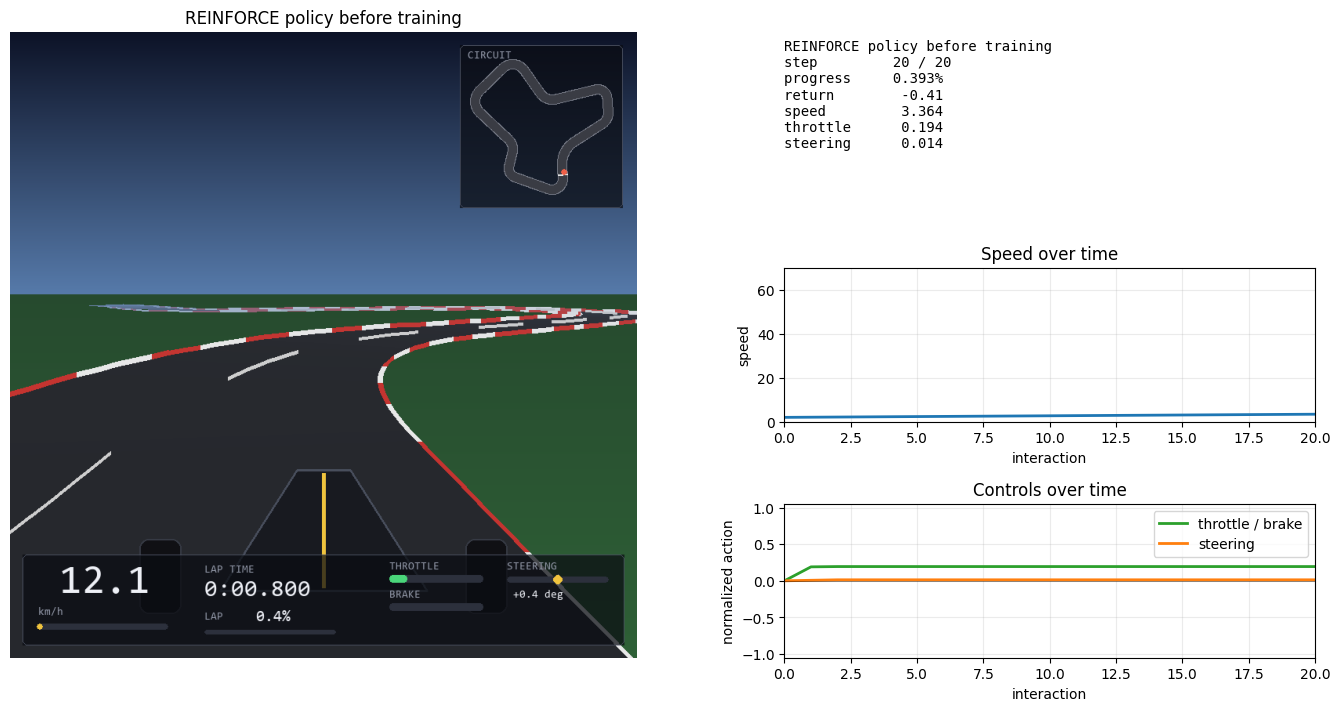

{'interactions': 20,
 'return': -0.4074378357049775,
 'collision': False,
 'lap_completed': False,
 'progress': 0.003925621642950225,
 'final_speed': 3.3638014793395996,
 'final_throttle': 0.19440598785877228,
 'final_steering': 0.013572520576417446}

In [3]:
initial_rollout = watch_deterministic_rollout(
    "REINFORCE policy before training",
    reference_track,
    agent,
    normalizer,
    ENVIRONMENT_CONFIG,
    max_steps=INITIAL_RENDER_STEPS,
    reset_seed=RENDER_RESET_SEED,
    viewer_mode=VIEWER_MODE,
    render_style=RENDER_STYLE,
    frame_delay=LIVE_FRAME_DELAY,
)
initial_rollout

## Scheduled greedy evaluation

Every evaluation checkpoint runs the deterministic actor for `EVALUATION_EPISODES` episodes with frozen normalization and independent reset seeds. Each plotted point is the mean return or progress at that checkpoint; the shaded region is plus or minus one population standard deviation across those episodes.

The current racing environment and canonical start are deterministic, so repeated greedy episodes on one fixed circuit normally have zero standard deviation. The band becomes informative when evaluation spans randomized starts or multiple fixed evaluation circuits.

In [4]:
def evaluation_row(evaluation):
    """
    Summarize one recorded evaluation for the plots below.

    The engine records far more than the curve needs, so the notebook takes
    what it plots from the record rather than the engine reporting a second,
    smaller shape that could drift from it.
    """
    episode = evaluation.record.episode
    return {
        "training_interactions": evaluation.record.training_interactions,
        "return_mean": episode.undiscounted_return,
        "return_standard_deviation": 0.0,
        "maximum_progress_mean": episode.maximum_progress,
        "maximum_progress_standard_deviation": 0.0,
        "lap_time_mean": episode.lap_time,
        "completed_fraction": float(episode.outcome.value == "completed"),
        "outcomes": [episode.outcome.value],
        "completed_training_episodes": None,
    }


def update_row(update):
    """
    Expose one optimizer update in the shape the diagnostic plots read.
    """
    return {
        "training_interactions": update.training_interactions,
        "diagnostics": update.output.diagnostics,
        "optimization_duration": update.optimization_duration,
    }


## Train to the common interaction budget

Each active worker collects one complete trajectory and then parks. The worker count is an execution choice shared with A2C and PPO, while the batch size belongs to REINFORCE, so a batch that needs more trajectories than there are workers is filled over several successive waves. No optimizer step separates those waves, so all eight trajectories still come from one policy, which is what the Monte Carlo estimator requires. If the interaction budget interrupts the final batch, those interactions still count toward the fair budget but incomplete trajectories are not used for an optimizer update.

In [5]:
try:
    state = engine.train(TRAINING_INTERACTION_BUDGET)
    episodes = list(engine.episode_records)
    evaluation_rows = [evaluation_row(row) for row in engine.evaluations]
    update_rows = [update_row(row) for row in engine.updates]
finally:
    engine.close()

print(f"Episodes completed: {len(episodes):,}")
print(f"Training interactions: {state.counters.training_interactions:,}")
print(f"Optimizer updates: {state.counters.optimizer_updates:,}")
print(f"Greedy evaluation checkpoints: {len(evaluation_rows):,}")

Episodes completed: 3,072
Training interactions: 2,000,000
Optimizer updates: 384
Greedy evaluation checkpoints: 40


## Prepare the recorded data

Episode rows retain return, outcome, circuit identity, maximum progress, interaction count, mean speed, and mean throttle magnitude. Update rows retain the REINFORCE loss, actor norm, and the two learned log standard deviations. The following sections deliberately separate task performance, progress/efficiency, driving behaviour, and optimization/exploration.

In [6]:
episode_rows = []
for record in episodes:
    row = asdict(record)
    row["outcome"] = record.outcome.value
    # The record keeps each signal's whole distribution; the curves below plot
    # one number per episode, so the mean is taken here rather than recorded
    # a second time in a shape that could drift from the first.
    row["mean_speed"] = record.speed.mean
    row["mean_throttle"] = record.throttle.mean
    episode_rows.append(row)

print("Last training episode:")
print(episode_rows[-1] if episode_rows else "No episode ended within the budget.")
print("\nLast optimizer update:")
print(update_rows[-1] if update_rows else "No complete REINFORCE batch was available.")
print("\nLast greedy evaluation:")
print(evaluation_rows[-1])

Last training episode:
{'run_category': <RunCategory.REDUCED_VALIDATION: 'reduced_budget_end_to_end_validation'>, 'scope': <MetricScope.TRAINING: 'training'>, 'episode_index': 3067, 'outcome': 'completed', 'undiscounted_return': 196.7912408243505, 'training_target_total': None, 'interactions': 737, 'simulated_time': 29.48, 'final_progress': 1.000009888628241, 'maximum_progress': 1.000009888628241, 'lap_time': 29.48, 'training_interactions': 1996865, 'evaluation_interactions': 24786, 'circuit_identity': '0', 'root_identity': 0, 'observation_type': 'frenet', 'circuit_seed': 0, 'circuit_split': None, 'collection_worker': 3, 'worker_episode_index': 383, 'speed': {'mean': 18.124382489793096, 'standard_deviation': 3.0747408674250463, 'minimum': 2.03037988370889, 'maximum': 22.12911904463051, 'quantiles': {'q25': 17.635032894141762, 'q50': 18.866926277607405, 'q75': 19.641613469962074, 'q90': 20.483076717658424}}, 'throttle': {'mean': 0.25712773895968105, 'standard_deviation': 0.4804460356400

## Task performance

Training return shows every stochastic training episode and its trailing mean. Greedy evaluation return is aggregated separately because it measures the deterministic policy without exploration noise.

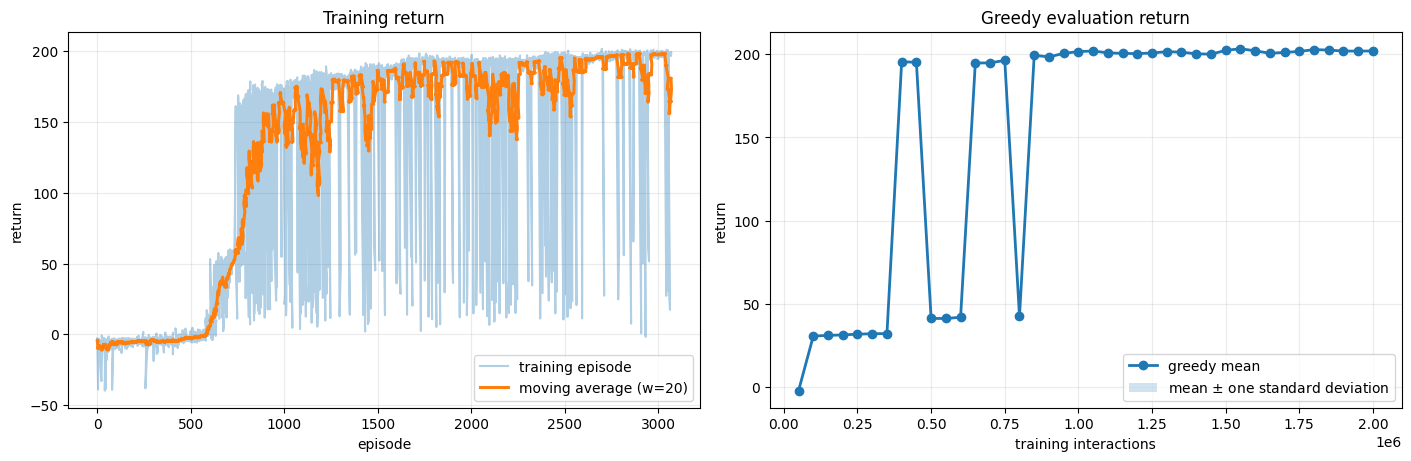

In [7]:
plot_task_performance(
    episode_rows,
    evaluation_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Progress and sample efficiency

Maximum progress prevents the shaped return from standing in for actual driving performance. Episode length reveals whether the policy crashes quickly, reaches the time limit, or completes laps in fewer interactions.

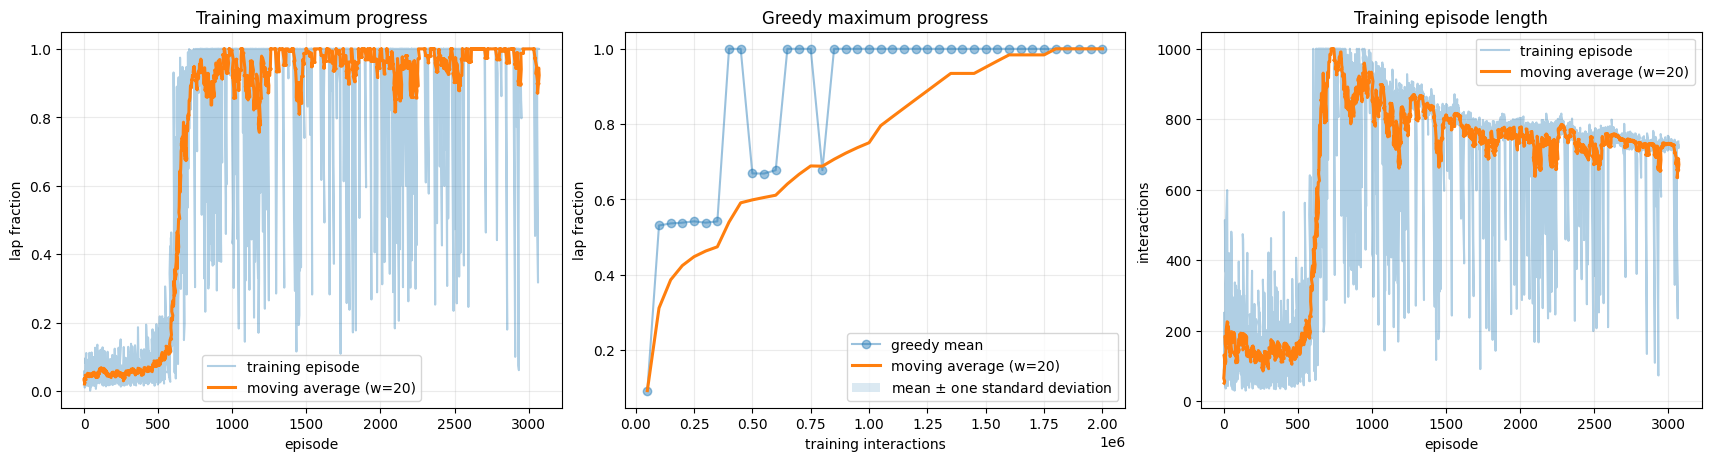

In [8]:
plot_progress_and_efficiency(
    episode_rows,
    evaluation_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Driving behaviour

Mean speed and mean absolute throttle/brake magnitude help distinguish genuine faster driving from stalled or overly aggressive policies.

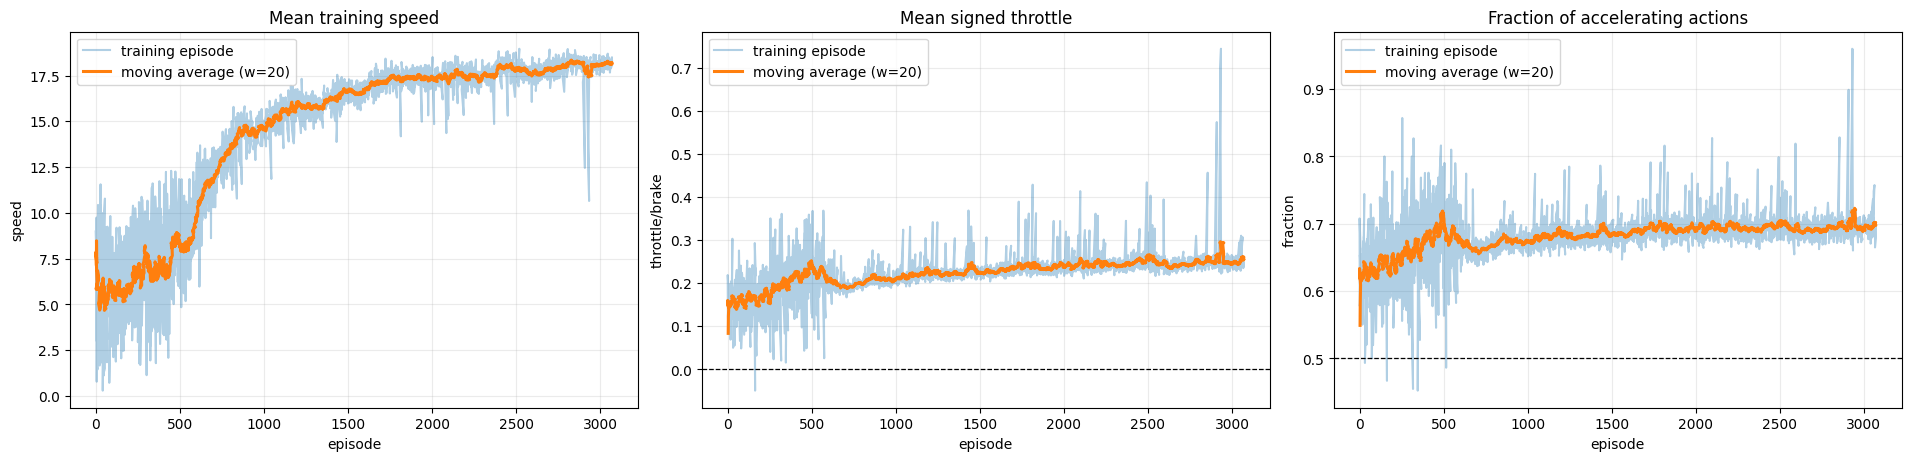

In [9]:
plot_driving_behavior(
    episode_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Outcomes and lap time

Return alone cannot say *why* a policy scores what it scores. The outcome mix separates crashing from idling from lapping, and lap time is the racing objective the return only summarizes.


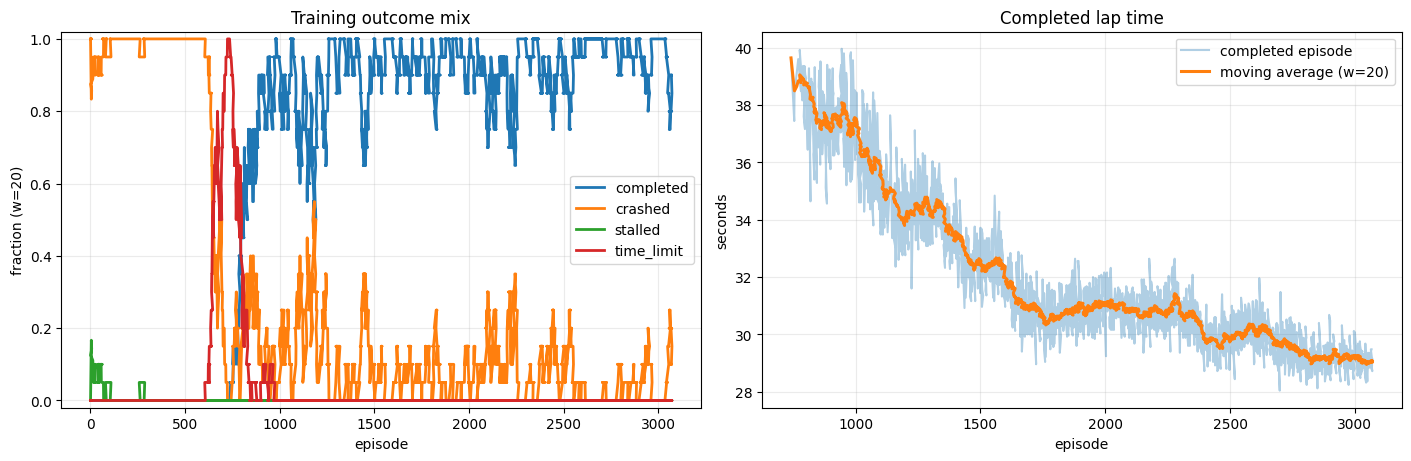

In [10]:
plot_outcomes_and_lap_time(
    episode_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Optimization and learned exploration

The REINFORCE loss is noisy because it is a Monte Carlo policy-gradient estimate, so its moving average is shown alongside every update. Actor weight norm tracks parameter scale. The two sigma curves are the actual learned exploration trace; there is no separate imposed decay schedule.

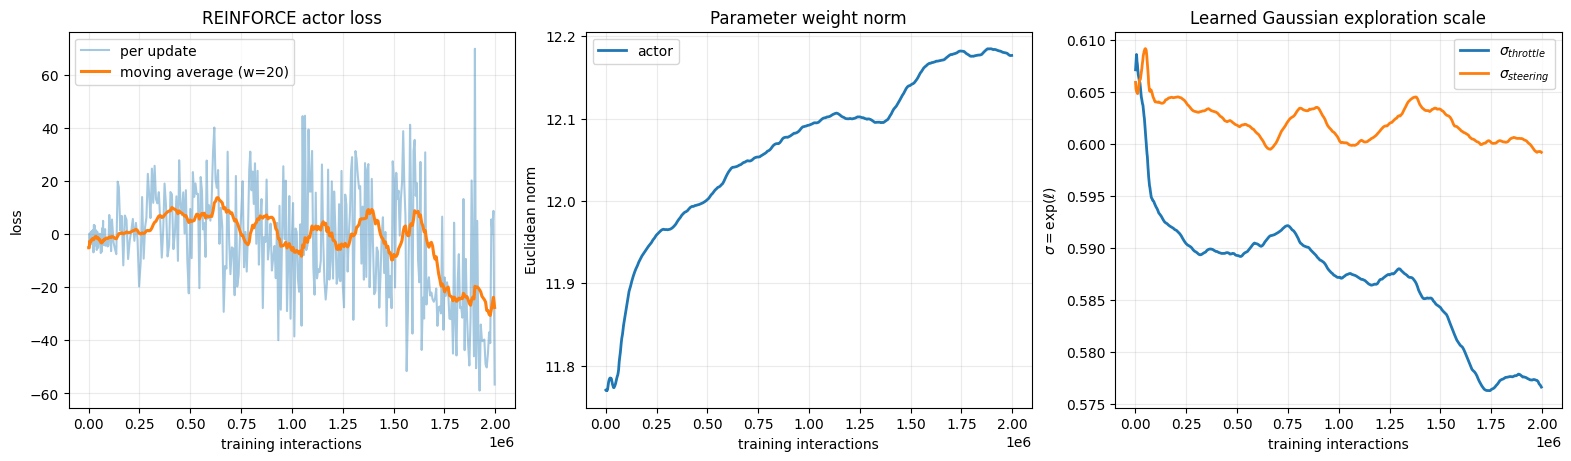

In [11]:
plot_optimization_and_exploration(
    update_rows,
    algorithm_name="REINFORCE",
    moving_average_window=MOVING_AVERAGE_WINDOW,
    include_critic=False,
)
plt.show()

## Policy after training

The final dashboard uses the same reference circuit, reset seed, deterministic action rule, and normalizer as the initial view, but permits all 1,000 environment actions. This makes the before/after comparison about the learned policy rather than a different circuit or exploration sample.

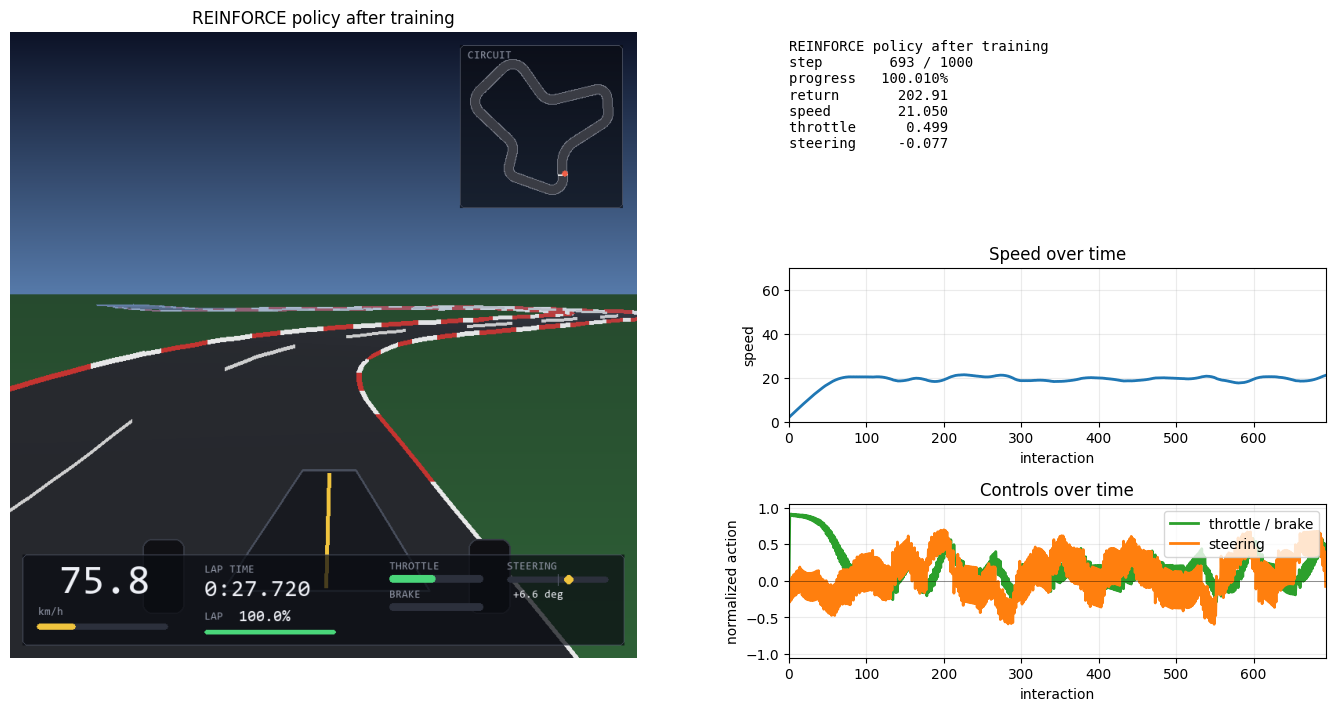

Before training: {'interactions': 20, 'return': -0.4074378357049775, 'collision': False, 'lap_completed': False, 'progress': 0.003925621642950225, 'final_speed': 3.3638014793395996, 'final_throttle': 0.19440598785877228, 'final_steering': 0.013572520576417446}
After training:  {'interactions': 693, 'return': 202.91279564297963, 'collision': False, 'lap_completed': True, 'progress': 1.000095932345236, 'final_speed': 21.049806594848633, 'final_throttle': 0.4992067813873291, 'final_steering': -0.07660969346761703}


In [12]:
final_rollout = watch_deterministic_rollout(
    "REINFORCE policy after training",
    reference_track,
    agent,
    normalizer,
    ENVIRONMENT_CONFIG,
    max_steps=FINAL_RENDER_STEPS,
    reset_seed=RENDER_RESET_SEED,
    viewer_mode=VIEWER_MODE,
    render_style=RENDER_STYLE,
    frame_delay=LIVE_FRAME_DELAY,
)
print("Before training:", initial_rollout)
print("After training: ", final_rollout)